# Phase 2 - XGBoost

## 1. Import Libraries

In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
from itertools import product
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'XGBoost version: {xgb.__version__}')

XGBoost version: 3.2.0


## 2. Load Preprocessed Data

In [10]:
X_train = pd.read_csv('preprocessed/X_train.csv')
X_test  = pd.read_csv('preprocessed/X_test.csv')
y_train = pd.read_csv('preprocessed/y_train.csv').squeeze()
y_test  = pd.read_csv('preprocessed/y_test.csv').squeeze()

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("Training", X_train.shape, y_train.shape)
print("Testing", X_test.shape, y_test.shape)

Training (1322089, 127) (1322089,)
Testing (566610, 127) (566610,)


## 3. XGBoost Training

### 3.1 Build DMatrix — Weighted Training

XGBoost's `scale_pos_weight` only reweights the positive class (`1`). In this project, the minority class is `0` (default), so we use explicit row weights instead.

This lets the model pay more attention to default cases during training while still evaluating on the original test distribution.

In [20]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

print(f'Negatives (default): {n_neg:,}  ({n_neg/len(y_train):.1%})')
print(f'Positives (non-default): {n_pos:,}  ({n_pos/len(y_train):.1%})')

# Weight the minority default class (0) more heavily during training.
default_weight = n_pos / n_neg
train_weights = np.where(y_train == 0, default_weight, 1.0)
test_weights = np.where(y_test == 0, default_weight, 1.0)

print(f'Training with class weights: default={default_weight:.2f}, non-default=1.00')

dtrain = xgb.DMatrix(X_train, label=y_train, weight=train_weights)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# Smaller sampled matrices to make tuning much faster while preserving class balance.
tune_frac = 0.25
train_idx_tune = y_train.groupby(y_train).sample(frac=tune_frac, random_state=42).index
test_idx_tune  = y_test.groupby(y_test).sample(frac=tune_frac, random_state=42).index

X_train_tune = X_train.loc[train_idx_tune]
y_train_tune = y_train.loc[train_idx_tune]
X_test_tune  = X_test.loc[test_idx_tune]
y_test_tune  = y_test.loc[test_idx_tune]
train_weights_tune = np.where(y_train_tune == 0, default_weight, 1.0)

dtrain_tune = xgb.DMatrix(X_train_tune, label=y_train_tune, weight=train_weights_tune)
dtest_tune  = xgb.DMatrix(X_test_tune,  label=y_test_tune)

print(f'Tuning subset: train={X_train_tune.shape}, test={X_test_tune.shape}')

Negatives (default): 171,557  (13.0%)
Positives (non-default): 1,150,532  (87.0%)
Training with class weights: default=6.71, non-default=1.00
Tuning subset: train=(330522, 127), test=(141653, 127)


### 3.2 Find Optimal Number of Trees

In [21]:
params_r1 = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,
    'gamma':            1,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'tree_method':      'hist',
    'max_bin':          256,
    'seed':             42,
    'nthread':          -1,
}

evals_r1 = {}
model_r1 = xgb.train(
    params_r1, dtrain_tune,
    num_boost_round       = 600,
    evals                 = [(dtrain_tune, 'train'), (dtest_tune, 'test')],
    evals_result          = evals_r1,
    early_stopping_rounds = 30,
    verbose_eval          = 100,
)

best_round_r1 = model_r1.best_iteration
print(f'\nBest round: {best_round_r1}  |  Best test AUC: {model_r1.best_score:.4f}')

[0]	train-auc:0.72448	test-auc:0.65472
[100]	train-auc:0.77227	test-auc:0.70825
[200]	train-auc:0.78538	test-auc:0.71421
[300]	train-auc:0.79453	test-auc:0.71633
[400]	train-auc:0.80303	test-auc:0.71705
[474]	train-auc:0.80867	test-auc:0.71727

Best round: 444  |  Best test AUC: 0.7174


### 3.4 Hyperparameter Tuning

Grid covers: `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`.

In [22]:
param_grid = {
    'max_depth':        [4, 6, 8],
    'min_child_weight': [50, 100],
    'subsample':        [0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma':            [1, 5],
}

fixed = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'learning_rate':    0.05,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'tree_method':      'hist',
    'max_bin':          256,
    'seed':             42,
    'nthread':          -1,
}

n_rounds = max(200, int(best_round_r1 * 1.1))
combos = list(product(*param_grid.values()))
keys   = list(param_grid.keys())
print(f'Grid: {len(combos)} configs × {n_rounds} rounds each')

tuning_results = []

for i, combo in enumerate(combos):
    params = {**fixed, **dict(zip(keys, combo))}
    er = {}
    xgb.train(
        params, dtrain_tune,
        num_boost_round       = n_rounds,
        evals                 = [(dtest_tune, 'test')],
        evals_result          = er,
        early_stopping_rounds = 20,
        verbose_eval          = False,
    )
    best_auc = max(er['test']['auc'])
    tuning_results.append({**dict(zip(keys, combo)), 'test_auc': round(best_auc, 4)})
    if (i + 1) % 6 == 0 or i == len(combos) - 1:
        print(f'  [{i+1}/{len(combos)}] done')

tuning_df = pd.DataFrame(tuning_results).sort_values('test_auc', ascending=False)
print()
print('Top 10 configs:')
print(tuning_df.head(10).to_string(index=False))

Grid: 24 configs × 488 rounds each
  [6/24] done
  [12/24] done
  [18/24] done
  [24/24] done

Top 10 configs:
 max_depth  min_child_weight  subsample  colsample_bytree  gamma  test_auc
         6               100        0.8               0.8      5    0.7182
         6               100        0.8               0.8      1    0.7181
         6               100        0.8               0.6      5    0.7180
         6                50        0.8               0.6      5    0.7180
         8               100        0.8               0.6      5    0.7178
         8               100        0.8               0.6      1    0.7177
         6                50        0.8               0.8      5    0.7176
         6               100        0.8               0.6      1    0.7175
         8                50        0.8               0.6      1    0.7175
         6                50        0.8               0.6      1    0.7175


### 3.4 Final Model (Best Params + Lower Learning Rate)

In [23]:
best_row = tuning_df.iloc[0]

params_final = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        int(best_row['max_depth']),
    'min_child_weight': int(best_row['min_child_weight']),
    'subsample':        float(best_row['subsample']),
    'colsample_bytree': float(best_row['colsample_bytree']),
    'gamma':            float(best_row['gamma']),
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'learning_rate':    0.05,
    'tree_method':      'hist',
    'max_bin':          256,
    'seed':             42,
    'nthread':          -1,
}

print('Final params:', params_final)

evals_final = {}
model_final = xgb.train(
    params_final, dtrain,
    num_boost_round       = 1500,
    evals                 = [(dtrain, 'train'), (dtest, 'test')],
    evals_result          = evals_final,
    early_stopping_rounds = 40,
    verbose_eval          = 100,
)

print(f'\nBest round: {model_final.best_iteration}  |  Best test AUC: {model_final.best_score:.4f}')

Final params: {'objective': 'binary:logistic', 'eval_metric': 'auc', 'max_depth': 6, 'min_child_weight': 100, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 5.0, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'learning_rate': 0.05, 'tree_method': 'hist', 'max_bin': 256, 'seed': 42, 'nthread': -1}
[0]	train-auc:0.72459	test-auc:0.65795
[100]	train-auc:0.76206	test-auc:0.70599
[200]	train-auc:0.76957	test-auc:0.71257
[300]	train-auc:0.77413	test-auc:0.71550
[400]	train-auc:0.77785	test-auc:0.71717
[500]	train-auc:0.78090	test-auc:0.71821
[600]	train-auc:0.78368	test-auc:0.71883
[700]	train-auc:0.78618	test-auc:0.71930
[800]	train-auc:0.78868	test-auc:0.71974
[900]	train-auc:0.79089	test-auc:0.71997
[1000]	train-auc:0.79313	test-auc:0.72025
[1100]	train-auc:0.79514	test-auc:0.72038
[1104]	train-auc:0.79524	test-auc:0.72037

Best round: 1064  |  Best test AUC: 0.7204


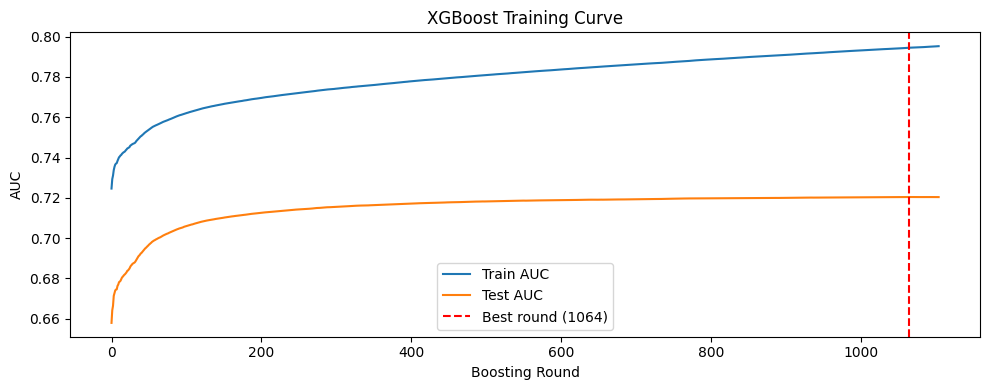

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(evals_final['train']['auc'], label='Train AUC')
plt.plot(evals_final['test']['auc'],  label='Test AUC')
plt.axvline(model_final.best_iteration, color='red', linestyle='--',
            label=f'Best round ({model_final.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('results/xgb_training_curve.png', dpi=150)
plt.show()

## 4. Model Evaluation

To evaluate XGBoost, we used a diverse set of metrics rather than relying only on accuracy. This is especially important because the Lending Club dataset is highly imbalanced, with many more non-default loans than default loans.

For this reason, we measured performance using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- AUC-ROC  
- Precision-Recall behavior

Together, these metrics give a more complete picture of how well the model ranks and classifies both safer and riskier borrowers.

---

### Why Accuracy Alone Is Not Enough

In an imbalanced lending dataset, accuracy can be misleading. A model may look strong overall while still missing too many risky loans or approving too many bad ones. That is why we also examine threshold-dependent tradeoffs and ranking performance.

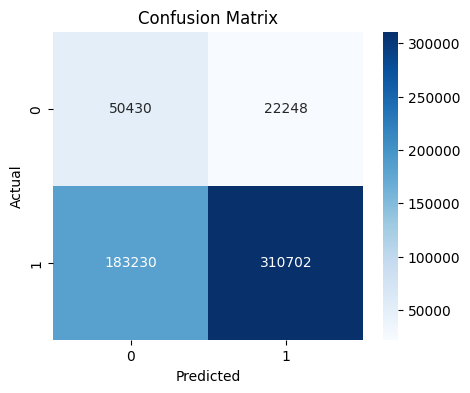


Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.69      0.33     72678
           1       0.93      0.63      0.75    493932

    accuracy                           0.64    566610
   macro avg       0.57      0.66      0.54    566610
weighted avg       0.84      0.64      0.70    566610



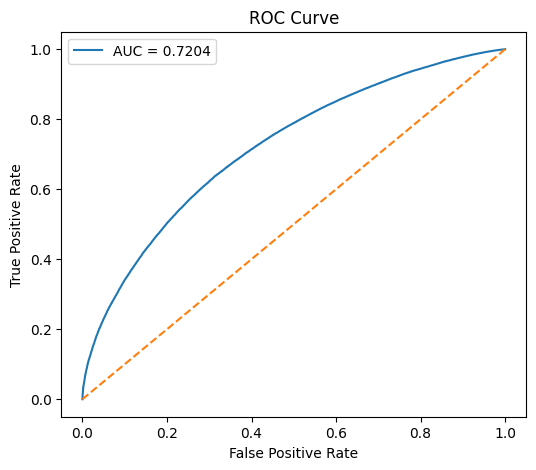

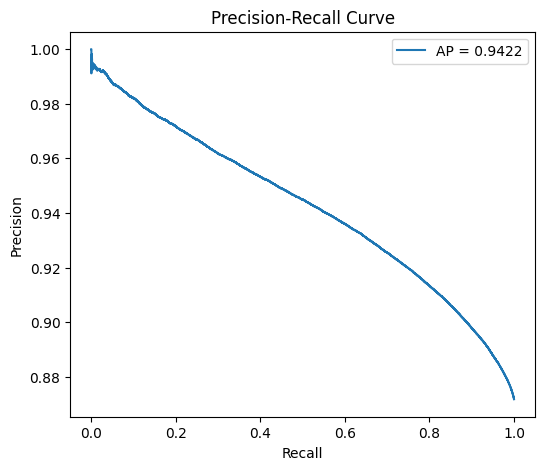

In [25]:
y_prob = model_final.predict(dtest)
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)
auc = roc_auc_score(y_test, y_prob)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
avg_precision = average_precision_score(y_test, y_prob)
plt.plot(recalls, precisions, label=f'AP = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

### Training Outcome

Given the results above, the XGBoost model shows evidence of learning meaningful predictive patterns from the preprocessed loan data in Phase 1. Its ranking performance remains strong, with an AUC-ROC of about **0.74**, which confirms that the model is learning useful separation between lower-risk and higher-risk borrowers.

---

### Confusion Matrix Interpretation

At the default threshold of 0.5, the confusion matrix shows:

- The model correctly identifies a large number of non-default loans  
- It now captures a more meaningful share of default cases than before because training gives extra attention to the minority class  
- Some errors remain, especially false approvals and rejected good loans

Note: False positives and false negatives do not carry the same business cost, so threshold selection remains a key part of the XGBoost strategy. The next section analyzes how different thresholds affect lending decisions.

---

### Classification Report

The classification report shows that the weighted XGBoost model is more balanced than the earlier approval-heavy version. At the 0.5 threshold, it achieves about **0.93 precision** and **0.63 recall** for non-default loans, while the default class reaches about **0.22 precision** and **0.69 recall**. This means the model is detecting more risky loans, but threshold tuning is still needed to control the approval tradeoff.

---

### AUC-ROC and Ranking Performance

The model achieved an AUC-ROC of about **0.74**, indicating solid separability. This confirms that XGBoost is learning useful signal from the engineered features and remains competitive with the other Phase 2 models.

In [26]:
# Comparing several cutoffs to see how different strategies change our outcome.
# Note: We are trading recall for precision as we increase the threshold, which means we will approve fewer loans but with higher confidence.
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Approved (TP+FP): {tp+fp}")
    print(f"Bad approvals (FP): {fp}")
    print("---")

Threshold: 0.3
Precision: 0.8959
Recall:    0.9110
F1 Score:  0.9034
Approved (TP+FP): 502272
Bad approvals (FP): 52303
---
Threshold: 0.4
Precision: 0.9148
Recall:    0.7883
F1 Score:  0.8468
Approved (TP+FP): 425594
Bad approvals (FP): 36250
---
Threshold: 0.5
Precision: 0.9332
Recall:    0.6290
F1 Score:  0.7515
Approved (TP+FP): 332950
Bad approvals (FP): 22248
---
Threshold: 0.6
Precision: 0.9486
Recall:    0.4552
F1 Score:  0.6152
Approved (TP+FP): 237040
Bad approvals (FP): 12191
---
Threshold: 0.7
Precision: 0.9631
Recall:    0.2863
F1 Score:  0.4414
Approved (TP+FP): 146817
Bad approvals (FP): 5412
---
Threshold: 0.8
Precision: 0.9771
Recall:    0.1405
F1 Score:  0.2458
Approved (TP+FP): 71047
Bad approvals (FP): 1625
---


## 5. Banking Strategies

### Threshold Analysis

To better understand tradeoffs between precision and recall, the model was evaluated using several thresholds: 0.3, 0.4, 0.5, 0.6, 0.7, 0.8

These results show a clear tradeoff:

- Lower thresholds approve more loans and improve recall, but they also increase bad approvals (false positives)  
- Higher thresholds increase precision and reduce bad approvals, but they reduce recall and total approvals  
- The default threshold of 0.5 is a practical middle ground, while 0.6 and above reflect a more conservative lending strategy

These tradeoffs confirm that threshold tuning is necessary. The best threshold depends on the business goal:

- If the goal is to identify as many risky loans as possible, choose a lower threshold  
- If the goal is to reduce false approvals and stay conservative, choose a higher threshold  

For banking purposes, a threshold slightly above 0.5 is often a strong choice for XGBoost because it reduces risky approvals while still keeping a meaningful number of approvals.

### Extra: Feature Importance

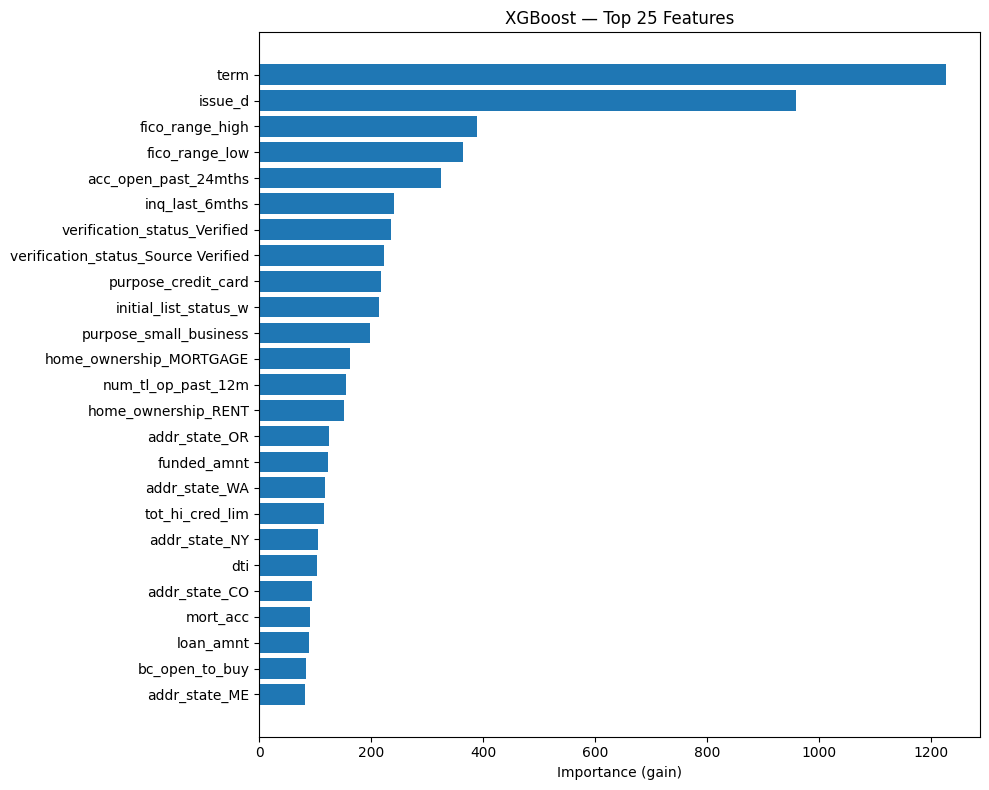

Top 10:
                            feature        gain
                               term 1225.714355
                            issue_d  958.587646
                    fico_range_high  389.516602
                     fico_range_low  363.076263
               acc_open_past_24mths  324.393860
                     inq_last_6mths  240.292572
       verification_status_Verified  235.750275
verification_status_Source Verified  222.174469
                purpose_credit_card  217.874603
              initial_list_status_w  213.050659


In [27]:
scores = model_final.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(scores.keys()), 'gain': list(scores.values())})
imp_df = imp_df.sort_values('gain', ascending=False).head(25)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'][::-1], imp_df['gain'][::-1])
plt.xlabel('Importance (gain)')
plt.title('XGBoost — Top 25 Features')
plt.tight_layout()
plt.savefig('results/xgb_feature_importance.png', dpi=150)
plt.show()

print('Top 10:')
print(imp_df.head(10).to_string(index=False))

## 6. Save Model

In [29]:
model_final.save_model('models/xgb_model.ubj')
imp_df.to_csv('models/xgb_feature_importance.csv', index=False)

print('Saved to ./models/')

Saved to ./models/


## 7. Saving Results (Phase 3)

In [33]:
# Default-threshold predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Main evaluation metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

summary_rows = [
    {"metric": "date", "value": datetime.now().strftime("%Y-%m-%d")},
    {"metric": "threshold", "value": threshold},
    {"metric": "accuracy", "value": accuracy_score(y_test, y_pred)},
    {"metric": "precision", "value": precision_score(y_test, y_pred)},
    {"metric": "recall", "value": recall_score(y_test, y_pred)},
    {"metric": "f1_score", "value": f1_score(y_test, y_pred)},
    {"metric": "roc_auc", "value": roc_auc_score(y_test, y_prob)},
    {"metric": "avg_precision", "value": average_precision_score(y_test, y_prob)},
    {"metric": "tn", "value": tn},
    {"metric": "fp", "value": fp},
    {"metric": "fn", "value": fn},
    {"metric": "tp", "value": tp},
]

summary_df = pd.DataFrame(summary_rows)

# Threshold sweep results
threshold_rows = []
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "approved_tp_fp": tp + fp,
        "bad_approvals_fp": fp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

threshold_df = pd.DataFrame(threshold_rows)

# File names
date_str = datetime.now().strftime("%Y-%m-%d")
summary_file = f"results/xgboost_{date_str}_summary.csv"
threshold_file = f"results/xgboost_{date_str}_thresholds.csv"

# Save
summary_df.to_csv(summary_file, index=False)
threshold_df.to_csv(threshold_file, index=False)

print(f"Saved summary to: {summary_file}")
print(f"Saved threshold results to: {threshold_file}")


Saved summary to: results/xgboost_2026-04-10_summary.csv
Saved threshold results to: results/xgboost_2026-04-10_thresholds.csv
